<a href="https://colab.research.google.com/github/inhajourney/AIFFEL_quest_cr/blob/main/Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Augmentation 적용

In [1]:
!pip install --upgrade pip

In [2]:
!pip install --upgrade torch torchvision

In [3]:
# PyTorch and torchvision
import torch
import torchvision

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

print('=3')

=3


In [4]:
# GPU 확인
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [5]:
!wget "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar" -P ~/work/data_augmentation/data
!tar -xf ~/work/data_augmentation/data/images.tar -C ~/work/data_augmentation/data/

--2026-01-22 06:37:17--  http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 793579520 (757M) [application/x-tar]
Saving to: ‘/root/work/data_augmentation/data/images.tar.1’

images.tar.1        100%[===================>] 756.82M  9.19MB/s    in 83s     

2026-01-22 06:38:40 (9.09 MB/s) - ‘/root/work/data_augmentation/data/images.tar.1’ saved [793579520/793579520]



In [6]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms

dataset_dir = "~/work/data_augmentation/data/Images/"

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 크기 통일
    transforms.ToTensor(),  # Tensor 변환
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # 정규화 추가
])
full_dataset = ImageFolder(root=dataset_dir, transform=transform)

total_size = len(full_dataset)
train_size = int(0.583 * total_size)  # 약 12,000개
test_size = total_size - train_size   # 약 8,580개
ds_train, ds_test = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(ds_train, batch_size=32, shuffle=True)
test_loader = DataLoader(ds_test, batch_size=32, shuffle=False)
ds_info = {
    "num_classes": len(full_dataset.classes),
    "class_names": full_dataset.classes
}

print("=3")

=3


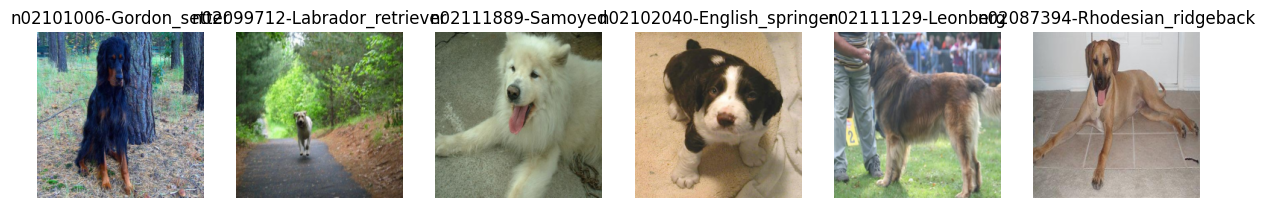

In [7]:
# DataLoader에서 일부 배치 가져오기
def show_examples(data_loader, class_names, num_images=6):
    data_iter = iter(data_loader)
    images, labels = next(data_iter)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        image = images[i].permute(1, 2, 0).numpy()  # (C, H, W) → (H, W, C)
        image = (image * 0.5) + 0.5
        image = np.clip(image, 0, 1)

        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(class_names[labels[i].item()])

    plt.show()

# 훈련 데이터 샘플 시각화
show_examples(train_loader, ds_info["class_names"])

In [8]:
def normalize_and_resize_img():
    return transforms.Compose([
        transforms.Resize((224, 224)),  # 크기 통일
        transforms.ToTensor(),  # Tensor 변환
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # 정규화 추가
    ])

In [9]:
def augment():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2)
    ])

print('=3')

=3


In [10]:
# 데이터셋을 가공하는 메인함수
def apply_normalize_on_dataset(dataset, is_test=False, batch_size=16, with_aug=False):
    transform = normalize_and_resize_img()

    if not is_test and with_aug:
        dataset.dataset.transform = transforms.Compose([
            *augment().transforms,
            *transform.transforms
        ])
    else:
        dataset.dataset.transform = transform

    return DataLoader(dataset, batch_size=batch_size, shuffle=not is_test, num_workers=2, pin_memory=True)

print('=3')

=3


In [11]:
import random

def augment2():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),  # 좌우 반전
        transforms.RandomVerticalFlip(p=0.5),    # 상하 반전
        transforms.RandomRotation(degrees=(0, 90, 180, 270)),  # 90도 단위 회전
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # 밝기, 대비, 색상 조정
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),  # 랜덤 크롭 후 리사이즈
        transforms.Lambda(lambda img: torch.clamp(img, 0, 1))  # 0~1 값으로 클리핑
    ])

print('=3')

=3


In [12]:
import torch.nn as nn
import torchvision.models as models

num_classes = len(ds_info["class_names"])
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)

model = nn.Sequential(
    resnet50,
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(resnet50.fc.in_features, num_classes),
    nn.Softmax(dim=1)
)

print("=3")


=3


In [13]:
aug_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
aug_resnet50.fc = nn.Linear(aug_resnet50.fc.in_features, num_classes)

aug_resnet50 = nn.Sequential(
    aug_resnet50,
    nn.Softmax(dim=1)
)

print("=3")

=3


In [14]:
import torch.nn as nn
import torchvision.models as models

num_classes = len(ds_info["class_names"])
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)

model = nn.Sequential(
    resnet50,
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(resnet50.fc.in_features, num_classes),
    nn.Softmax(dim=1)
)

print("=3")


=3


In [15]:
aug_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
aug_resnet50.fc = nn.Linear(aug_resnet50.fc.in_features, num_classes)

aug_resnet50 = nn.Sequential(
    aug_resnet50,
    nn.Softmax(dim=1)
)

print("=3")

=3


In [16]:
ds_train_no_aug = apply_normalize_on_dataset(ds_train, with_aug=False)
ds_train_aug = apply_normalize_on_dataset(ds_train, with_aug=True)
ds_test = apply_normalize_on_dataset(ds_test, is_test=True)

print("=3")

=3


In [17]:
%%time
import torch.optim as optim

#EPOCH = 20  # Augentation 적용 효과를 확인하기 위해 필요한 epoch 수
EPOCH = 3
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet50.parameters(), lr=0.001)

def train(model, train_loader, test_loader, epochs):
    model.to(device)
    history = {'val_accuracy': []}

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{epochs}], Accuracy: {train_acc:.2f}%")

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        history['val_accuracy'].append(val_acc)
        print(f"Validation Accuracy: {val_acc:.2f}%")

    return history

history_resnet50_no_aug = train(resnet50, ds_train_no_aug, ds_test, EPOCH)

Epoch [1/3], Accuracy: 16.33%
Validation Accuracy: 39.05%
Epoch [2/3], Accuracy: 45.63%
Validation Accuracy: 59.92%
Epoch [3/3], Accuracy: 60.94%
Validation Accuracy: 69.23%
CPU times: user 6min 3s, sys: 11.8 s, total: 6min 15s
Wall time: 7min 52s


In [19]:
%%time
history_resnet50_aug = train(aug_resnet50, ds_train_aug, ds_test, EPOCH)

Epoch [1/3], Accuracy: 0.46%
Validation Accuracy: 0.50%
Epoch [2/3], Accuracy: 0.43%
Validation Accuracy: 0.47%
Epoch [3/3], Accuracy: 0.46%
Validation Accuracy: 0.43%
CPU times: user 6min 17s, sys: 11 s, total: 6min 28s
Wall time: 7min 57s


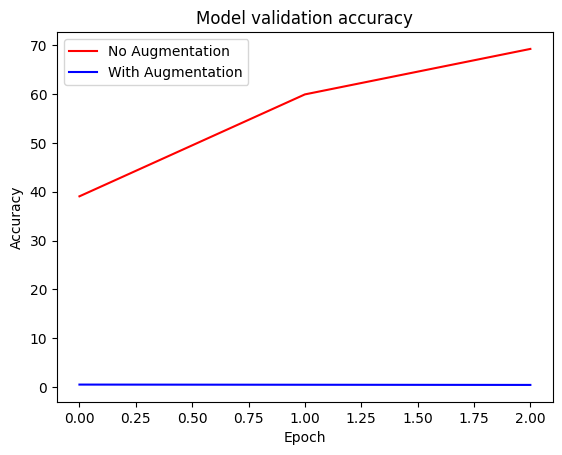

In [20]:
plt.plot(history_resnet50_no_aug['val_accuracy'], 'r', label='No Augmentation')
plt.plot(history_resnet50_aug['val_accuracy'], 'b', label='With Augmentation')
plt.title('Model validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

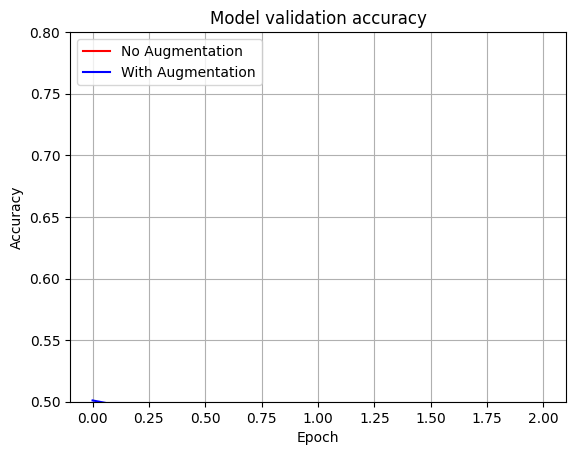

In [21]:
plt.plot(history_resnet50_no_aug['val_accuracy'], 'r', label='No Augmentation')
plt.plot(history_resnet50_aug['val_accuracy'], 'b', label='With Augmentation')
plt.title('Model validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.ylim(0.50, 0.80)    # 출력하고자 하는  Accuracy 범위를 지정해 주세요.
#plt.ylim(0.72, 0.76)  # EPOCH=20으로 진행한다면 이 범위가 적당합니다.
plt.show()

2. 심화 기법

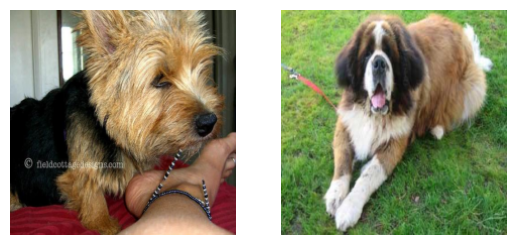

In [22]:
import matplotlib.pyplot as plt

# 데이터셋에서 이미지 2개를 가져옵니다.
data_iter = iter(ds_train_no_aug)
images, labels = next(data_iter)

# 첫 번째 배치에서 두 개의 이미지 선택
image_a = images[0].permute(1, 2, 0).numpy()
image_b = images[1].permute(1, 2, 0).numpy()
label_a = labels[0].item()
label_b = labels[1].item()

# 정규화된 텐서를 다시 [0, 1] 범위로 조정
image_a = (image_a * 0.5) + 0.5
image_b = (image_b * 0.5) + 0.5

# 이미지 출력
plt.subplot(1, 2, 1)
plt.imshow(image_a)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_b)
plt.axis('off')

plt.show()

In [23]:
def get_clip_box(image_a, image_b):
    # image.shape = (channel, height, width)
    image_size_x = image_a.shape[2]  # Width
    image_size_y = image_a.shape[1]  # Height

    # Get center of box
    x = torch.randint(0, image_size_x, (1,)).item()
    y = torch.randint(0, image_size_y, (1,)).item()

    width = max(1, int(image_size_x * torch.sqrt(1 - torch.rand(1)).item()))
    height = max(1, int(image_size_y * torch.sqrt(1 - torch.rand(1)).item()))

    # Clip box in image and get minmax bbox
    x_min = max(0, x - width // 2)
    y_min = max(0, y - height // 2)
    x_max = min(image_size_x, x + width // 2 + 1)
    y_max = min(image_size_y, y + height // 2 + 1)

    return x_min, y_min, x_max, y_max

x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)

print('x :', x_min, x_max)
print('y :', y_min, y_max)

x : 0 3
y : 104 224


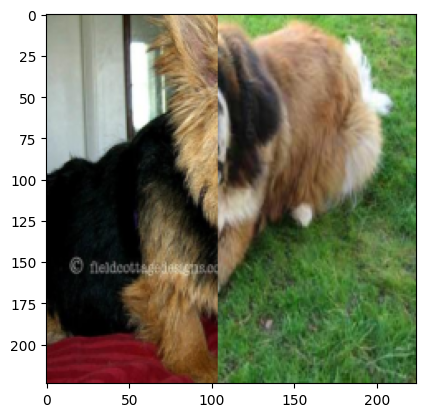

In [24]:
import torch

def mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max):
    # image.shape = (C, H, W)
    image_size_x = image_a.shape[2]  # Width
    image_size_y = image_a.shape[1]  # Height

    if isinstance(image_a, np.ndarray):
        image_a = torch.from_numpy(image_a).to(device)
    if isinstance(image_b, np.ndarray):
        image_b = torch.from_numpy(image_b).to(device)

    top = image_a[:, :y_min, :]
    middle_left = image_a[:, y_min:y_max, :x_min]
    middle_center = image_b[:, y_min:y_max, x_min:x_max]
    middle_right = image_a[:, y_min:y_max, x_max:]
    bottom = image_a[:, y_max:, :]

    top = top.to(device)
    middle_left = middle_left.to(device)
    middle_center = middle_center.to(device)
    middle_right = middle_right.to(device)
    bottom = bottom.to(device)

    # 중간 부분(왼쪽, 중앙, 오른쪽) 결합
    middle = torch.cat([middle_left, middle_center, middle_right], dim=2)

    # 전체 이미지 결합 (위 + 중간 + 아래)
    mixed_img = torch.cat([top, middle, bottom], dim=1)

    return mixed_img

mixed_img = mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max)

plt.imshow(mixed_img.cpu().numpy())
plt.show()

In [25]:
import torch.nn.functional as F

# mix two labels
def mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, num_classes=120):
    image_size_x = image_a.shape[2]  # Width
    image_size_y = image_a.shape[1]  # Height

    # 바운딩 박스 비율 계산
    mixed_area = (x_max - x_min) * (y_max - y_min)
    total_area = image_size_x * image_size_y
    ratio = mixed_area / total_area

     # 원-핫 벡터 변환
    if isinstance(label_a, int):
        label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    if isinstance(label_b, int):
        label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    # 비율에 따라 라벨 혼합
    mixed_label = (1 - ratio) * label_a + ratio * label_b
    return mixed_label

# 예제 실행
mixed_label = mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max)
print(mixed_label)

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.4643,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.5357, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [26]:
def cutmix(images, labels, prob=1.0, batch_size=16, img_size=224, num_classes=120):
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i]

        j = torch.randint(0, batch_size, (1,)).item()  # 다른 샘플 선택
        image_b = images[j]
        label_b = labels[j]

        # 바운딩 박스 생성
        x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)

        # 이미지 섞기
        mixed_imgs.append(mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max))
        mixed_labels.append(mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, num_classes))

    # 텐서 변환
    mixed_imgs = torch.stack(mixed_imgs).reshape(batch_size, 3, img_size, img_size)
    mixed_labels = torch.stack(mixed_labels).reshape(batch_size, num_classes)

    return mixed_imgs, mixed_labels

print("=3")

=3


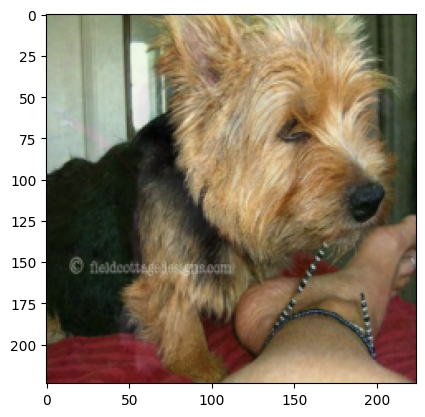

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.8483,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.1517, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [27]:
# function for mixup
def mixup_2_images(image_a, image_b, label_a, label_b, num_classes=120):
    ratio = torch.rand(1).item()  # 0~1 사이의 랜덤 값

    # 라벨 원핫 인코딩
    if isinstance(label_a, int):
        label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    if isinstance(label_b, int):
        label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    # 이미지와 라벨 혼합
    mixed_image = (1 - ratio) * image_a + ratio * image_b
    mixed_label = (1 - ratio) * label_a + ratio * label_b

    return mixed_image, mixed_label

# 예제 실행
mixed_img, mixed_label = mixup_2_images(image_a, image_b, label_a, label_b)

plt.imshow(mixed_img)
plt.show()

print(mixed_label)

In [28]:
def mixup(images, labels, batch_size=16, img_size=224, num_classes=120):
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i]

        # 랜덤하게 다른 이미지 선택
        j = torch.randint(0, batch_size, (1,)).item()
        image_b = images[j]
        label_b = labels[j]

        # Mixup 적용
        mixed_img, mixed_label = mixup_2_images(image_a, image_b, label_a, label_b, num_classes)

        mixed_imgs.append(mixed_img)
        mixed_labels.append(mixed_label)

    # 배치 차원 추가
    mixed_imgs = torch.stack(mixed_imgs).view(batch_size, 3, img_size, img_size)  # (B, C, H, W)
    mixed_labels = torch.stack(mixed_labels).view(batch_size, num_classes)  # (B, num_classes)

    return mixed_imgs, mixed_labels

print('=3')

=3


# 프로젝트: Mixup 또는 CutMix 비교실험 하기

In [29]:
# ========== 1️⃣ Mixup & CutMix 함수 (이미 구현된 버전 사용) ==========

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# 이미 작성된 함수들을 그대로 사용
def get_clip_box(image_a, image_b):
    """CutMix용 클립 박스 생성"""
    image_size_x = image_a.shape[2]  # Width
    image_size_y = image_a.shape[1]  # Height

    x = torch.randint(0, image_size_x, (1,)).item()
    y = torch.randint(0, image_size_y, (1,)).item()

    width = max(1, int(image_size_x * torch.sqrt(1 - torch.rand(1)).item()))
    height = max(1, int(image_size_y * torch.sqrt(1 - torch.rand(1)).item()))

    x_min = max(0, x - width // 2)
    y_min = max(0, y - height // 2)
    x_max = min(image_size_x, x + width // 2 + 1)
    y_max = min(image_size_y, y + height // 2 + 1)

    return x_min, y_min, x_max, y_max


def mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max):
    """두 이미지를 CutMix로 섞기"""
    if isinstance(image_a, np.ndarray):
        image_a = torch.from_numpy(image_a)
    if isinstance(image_b, np.ndarray):
        image_b = torch.from_numpy(image_b)

    top = image_a[:, :y_min, :]
    middle_left = image_a[:, y_min:y_max, :x_min]
    middle_center = image_b[:, y_min:y_max, x_min:x_max]
    middle_right = image_a[:, y_min:y_max, x_max:]
    bottom = image_a[:, y_max:, :]

    middle = torch.cat([middle_left, middle_center, middle_right], dim=2)
    mixed_img = torch.cat([top, middle, bottom], dim=1)

    return mixed_img


def mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, image_a, num_classes=120):
    """두 레이블을 CutMix 비율에 따라 섞기"""
    image_size_x = image_a.shape[2]
    image_size_y = image_a.shape[1]

    mixed_area = (x_max - x_min) * (y_max - y_min)
    total_area = image_size_x * image_size_y
    ratio = mixed_area / total_area

    if isinstance(label_a, int):
        label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    if isinstance(label_b, int):
        label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    mixed_label = (1 - ratio) * label_a + ratio * label_b
    return mixed_label


def cutmix(images, labels, batch_size=16, img_size=224, num_classes=120):
    """배치 전체에 CutMix 적용"""
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i]

        j = torch.randint(0, batch_size, (1,)).item()
        image_b = images[j]
        label_b = labels[j]

        x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)

        mixed_imgs.append(mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max))
        mixed_labels.append(mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, image_a, num_classes))

    mixed_imgs = torch.stack(mixed_imgs).reshape(batch_size, 3, img_size, img_size)
    mixed_labels = torch.stack(mixed_labels).reshape(batch_size, num_classes)

    return mixed_imgs, mixed_labels


def mixup_2_images(image_a, image_b, label_a, label_b, num_classes=120):
    """두 이미지를 Mixup으로 섞기"""
    ratio = torch.rand(1).item()

    if isinstance(label_a, int):
        label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    if isinstance(label_b, int):
        label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    mixed_image = (1 - ratio) * image_a + ratio * image_b
    mixed_label = (1 - ratio) * label_a + ratio * label_b

    return mixed_image, mixed_label


def mixup(images, labels, batch_size=16, img_size=224, num_classes=120):
    """배치 전체에 Mixup 적용"""
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i]

        j = torch.randint(0, batch_size, (1,)).item()
        image_b = images[j]
        label_b = labels[j]

        mixed_img, mixed_label = mixup_2_images(image_a, image_b, label_a, label_b, num_classes)

        mixed_imgs.append(mixed_img)
        mixed_labels.append(mixed_label)

    mixed_imgs = torch.stack(mixed_imgs).view(batch_size, 3, img_size, img_size)
    mixed_labels = torch.stack(mixed_labels).view(batch_size, num_classes)

    return mixed_imgs, mixed_labels


print("✅ Mixup & CutMix 함수 준비 완료")


✅ Mixup & CutMix 함수 준비 완료


In [30]:
# ========== 2️⃣ 모델 만들기 ==========

import torch.nn as nn
import torchvision.models as models

num_classes = ds_info["num_classes"]

# 모델 1: No Augmentation
print("\n" + "="*50)
print("모델 1: No Augmentation")
print("="*50)
resnet50_no_aug = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50_no_aug.fc = nn.Linear(resnet50_no_aug.fc.in_features, num_classes)

# 모델 2: Basic Augmentation
print("\n" + "="*50)
print("모델 2: Basic Augmentation")
print("="*50)
resnet50_basic_aug = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50_basic_aug.fc = nn.Linear(resnet50_basic_aug.fc.in_features, num_classes)

# 모델 3: Mixup
print("\n" + "="*50)
print("모델 3: With Mixup")
print("="*50)
resnet50_mixup = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50_mixup.fc = nn.Linear(resnet50_mixup.fc.in_features, num_classes)

# 모델 4: CutMix
print("\n" + "="*50)
print("모델 4: With CutMix")
print("="*50)
resnet50_cutmix = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50_cutmix.fc = nn.Linear(resnet50_cutmix.fc.in_features, num_classes)

print("\n✅ 모든 모델 생성 완료!")



모델 1: No Augmentation

모델 2: Basic Augmentation

모델 3: With Mixup

모델 4: With CutMix

✅ 모든 모델 생성 완료!


In [31]:
# ========== 3️⃣ 데이터셋 준비 ==========

# 기본 데이터셋 (이미 만들어져 있음)
ds_train_no_aug = apply_normalize_on_dataset(ds_train, with_aug=False, batch_size=32)
ds_train_basic_aug = apply_normalize_on_dataset(ds_train, with_aug=True, batch_size=32)
ds_test = apply_normalize_on_dataset(ds_test, is_test=True, batch_size=32)

# Mixup과 CutMix용 데이터셋은 훈련 중에 동적으로 적용
print("✅ 데이터셋 준비 완료")


# ========== 3️⃣ 모델 훈련 함수 ==========

import torch.optim as optim

def train_with_augmentation(model, train_loader, test_loader, epochs,
                           use_mixup=False, use_cutmix=False, model_name="Model"):
    """
    Mixup/CutMix를 지원하는 훈련 함수
    """
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

    history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_accuracy': [],
        'val_loss': []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Mixup 또는 CutMix 적용
            if use_mixup:
                images, labels = mixup(images, labels,
                                      batch_size=images.size(0),
                                      num_classes=num_classes)
                images, labels = images.to(device), labels.to(device)
            elif use_cutmix:
                images, labels = cutmix(images, labels,
                                       batch_size=images.size(0),
                                       num_classes=num_classes)
                images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            # Mixup/CutMix는 one-hot 레이블, 일반은 정수 레이블
            if use_mixup or use_cutmix:
                # one-hot 레이블과의 loss 계산
                loss = -(labels * F.log_softmax(outputs, dim=1)).sum(dim=1).mean()
            else:
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Accuracy 계산
            _, predicted = outputs.max(1)
            total += labels.size(0)
            if use_mixup or use_cutmix:
                # one-hot에서 argmax
                correct += predicted.eq(labels.argmax(dim=1)).sum().item()
            else:
                correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_acc)

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_acc = 100. * val_correct / val_total
        val_loss = val_loss / len(test_loader)
        history['val_accuracy'].append(val_acc)
        history['val_loss'].append(val_loss)

        print(f"[{model_name}] Epoch [{epoch+1}/{epochs}]")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return history


✅ 데이터셋 준비 완료


In [32]:
# ========== 훈련 실행 (EPOCH=3) ==========

EPOCHS = 3  # 빠른 테스트용

print("\n" + "="*50)
print("🚀 훈련 시작 (EPOCHS=3)")
print("="*50)

# 1. No Augmentation
print("\n[1/4] No Augmentation 모델 훈련...")
history_no_aug = train_with_augmentation(
    resnet50_no_aug,
    ds_train_no_aug,
    ds_test,
    EPOCHS,
    use_mixup=False,
    use_cutmix=False,
    model_name="No Aug"
)

# 2. Basic Augmentation
print("\n[2/4] Basic Augmentation 모델 훈련...")
history_basic_aug = train_with_augmentation(
    resnet50_basic_aug,
    ds_train_basic_aug,
    ds_test,
    EPOCHS,
    use_mixup=False,
    use_cutmix=False,
    model_name="Basic Aug"
)

# 3. Mixup (기본 augmentation + Mixup)
print("\n[3/4] Mixup 모델 훈련...")
history_mixup = train_with_augmentation(
    resnet50_mixup,
    ds_train_basic_aug,  # 기본 augmentation 포함
    ds_test,
    EPOCHS,
    use_mixup=True,
    use_cutmix=False,
    model_name="Mixup"
)

# 4. CutMix (기본 augmentation + CutMix)
print("\n[4/4] CutMix 모델 훈련...")
history_cutmix = train_with_augmentation(
    resnet50_cutmix,
    ds_train_basic_aug,  # 기본 augmentation 포함
    ds_test,
    EPOCHS,
    use_mixup=False,
    use_cutmix=True,
    model_name="CutMix"
)

print("\n✅ 모든 모델 훈련 완료!")



🚀 훈련 시작 (EPOCHS=3)

[1/4] No Augmentation 모델 훈련...


TypeError: Caught TypeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
TypeError: 'DataLoader' object is not subscriptable


In [34]:
## 오류 수정 apply_normalize_on_dataset 함수 DataLoader를 반환

# ========== 2️⃣ 모델 만들기 ==========

import torch.nn as nn
import torchvision.models as models

num_classes = ds_info["num_classes"]

# 모델 1: No Augmentation
print("\n" + "="*50)
print("모델 1: No Augmentation")
print("="*50)
resnet50_no_aug = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50_no_aug.fc = nn.Linear(resnet50_no_aug.fc.in_features, num_classes)

# 모델 2: Basic Augmentation
print("\n" + "="*50)
print("모델 2: Basic Augmentation")
print("="*50)
resnet50_basic_aug = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50_basic_aug.fc = nn.Linear(resnet50_basic_aug.fc.in_features, num_classes)

# 모델 3: Mixup
print("\n" + "="*50)
print("모델 3: With Mixup")
print("="*50)
resnet50_mixup = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50_mixup.fc = nn.Linear(resnet50_mixup.fc.in_features, num_classes)

# 모델 4: CutMix
print("\n" + "="*50)
print("모델 4: With CutMix")
print("="*50)
resnet50_cutmix = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50_cutmix.fc = nn.Linear(resnet50_cutmix.fc.in_features, num_classes)

print("\n✅ 모든 모델 생성 완료!")


# ========== 3️⃣ 데이터셋 준비 (수정됨) ==========

# apply_normalize_on_dataset이 이미 DataLoader를 반환하므로 그대로 사용
train_loader_no_aug = apply_normalize_on_dataset(ds_train, with_aug=False, batch_size=32)
train_loader_basic_aug = apply_normalize_on_dataset(ds_train, with_aug=True, batch_size=32)
test_loader = apply_normalize_on_dataset(ds_test, is_test=True, batch_size=32)

print("✅ 데이터셋 준비 완료")


모델 1: No Augmentation

모델 2: Basic Augmentation

모델 3: With Mixup

모델 4: With CutMix

✅ 모든 모델 생성 완료!
✅ 데이터셋 준비 완료


In [35]:
# ========== 4️⃣ 모델 훈련 함수 ==========

import torch.optim as optim

def train_with_augmentation(model, train_loader, test_loader, epochs,
                           use_mixup=False, use_cutmix=False, model_name="Model"):
    """
    Mixup/CutMix를 지원하는 훈련 함수
    """
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

    history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_accuracy': [],
        'val_loss': []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Mixup 또는 CutMix 적용
            if use_mixup:
                images, labels = mixup(images, labels,
                                      batch_size=images.size(0),
                                      num_classes=num_classes)
                images, labels = images.to(device), labels.to(device)
            elif use_cutmix:
                images, labels = cutmix(images, labels,
                                       batch_size=images.size(0),
                                       num_classes=num_classes)
                images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            # Mixup/CutMix는 one-hot 레이블, 일반은 정수 레이블
            if use_mixup or use_cutmix:
                # one-hot 레이블과의 loss 계산
                loss = -(labels * F.log_softmax(outputs, dim=1)).sum(dim=1).mean()
            else:
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Accuracy 계산
            _, predicted = outputs.max(1)
            total += labels.size(0)
            if use_mixup or use_cutmix:
                # one-hot에서 argmax
                correct += predicted.eq(labels.argmax(dim=1)).sum().item()
            else:
                correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_acc)

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_acc = 100. * val_correct / val_total
        val_loss = val_loss / len(test_loader)
        history['val_accuracy'].append(val_acc)
        history['val_loss'].append(val_loss)

        print(f"[{model_name}] Epoch [{epoch+1}/{epochs}]")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return history

In [36]:
# ========== 5️⃣ 훈련 실행 (EPOCH=3) ==========

EPOCHS = 3

print("\n" + "="*50)
print("🚀 훈련 시작 (EPOCHS=3)")
print("="*50)

# 1. No Augmentation
print("\n[1/4] No Augmentation 모델 훈련...")
history_no_aug = train_with_augmentation(
    resnet50_no_aug,
    train_loader_no_aug,  # 수정됨
    test_loader,          # 수정됨
    EPOCHS,
    use_mixup=False,
    use_cutmix=False,
    model_name="No Aug"
)

# 2. Basic Augmentation
print("\n[2/4] Basic Augmentation 모델 훈련...")
history_basic_aug = train_with_augmentation(
    resnet50_basic_aug,
    train_loader_basic_aug,  # 수정됨
    test_loader,             # 수정됨
    EPOCHS,
    use_mixup=False,
    use_cutmix=False,
    model_name="Basic Aug"
)

# 3. Mixup (기본 augmentation + Mixup)
print("\n[3/4] Mixup 모델 훈련...")
history_mixup = train_with_augmentation(
    resnet50_mixup,
    train_loader_basic_aug,  # 수정됨
    test_loader,             # 수정됨
    EPOCHS,
    use_mixup=True,
    use_cutmix=False,
    model_name="Mixup"
)

# 4. CutMix (기본 augmentation + CutMix)
print("\n[4/4] CutMix 모델 훈련...")
history_cutmix = train_with_augmentation(
    resnet50_cutmix,
    train_loader_basic_aug,  # 수정됨
    test_loader,             # 수정됨
    EPOCHS,
    use_mixup=False,
    use_cutmix=True,
    model_name="CutMix"
)

print("\n✅ 모든 모델 훈련 완료!")




🚀 훈련 시작 (EPOCHS=3)

[1/4] No Augmentation 모델 훈련...


TypeError: Caught TypeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
TypeError: 'DataLoader' object is not subscriptable


In [37]:

# ========== 3️⃣ 데이터 로더 생성 (완전히 새로 작성) ==========

from torch.utils.data import DataLoader
import torchvision.transforms as transforms

print("\n" + "="*50)
print("데이터 로더 생성 중...")
print("="*50)

# Transform 정의
transform_no_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_with_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 각 데이터셋에 transform 적용
# No Augmentation용
ds_train.dataset.transform = transform_no_aug
train_loader_no_aug = DataLoader(ds_train, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

# Basic Augmentation용 (Mixup, CutMix도 이것 사용)
ds_train.dataset.transform = transform_with_aug
train_loader_basic_aug = DataLoader(ds_train, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)

# Test 데이터
ds_test.dataset.transform = transform_no_aug
test_loader = DataLoader(ds_test, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("✅ 데이터 로더 준비 완료")



데이터 로더 생성 중...
✅ 데이터 로더 준비 완료


In [38]:
#  ========== 4️⃣ 모델 훈련 함수 ==========

import torch.optim as optim

def train_with_augmentation(model, train_loader, test_loader, epochs,
                           use_mixup=False, use_cutmix=False, model_name="Model"):
    """
    Mixup/CutMix를 지원하는 훈련 함수
    """
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

    history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_accuracy': [],
        'val_loss': []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Mixup 또는 CutMix 적용
            if use_mixup:
                images, labels = mixup(images, labels,
                                      batch_size=images.size(0),
                                      num_classes=num_classes)
                images, labels = images.to(device), labels.to(device)
            elif use_cutmix:
                images, labels = cutmix(images, labels,
                                       batch_size=images.size(0),
                                       num_classes=num_classes)
                images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            # Mixup/CutMix는 one-hot 레이블, 일반은 정수 레이블
            if use_mixup or use_cutmix:
                # one-hot 레이블과의 loss 계산
                loss = -(labels * F.log_softmax(outputs, dim=1)).sum(dim=1).mean()
            else:
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Accuracy 계산
            _, predicted = outputs.max(1)
            total += labels.size(0)
            if use_mixup or use_cutmix:
                # one-hot에서 argmax
                correct += predicted.eq(labels.argmax(dim=1)).sum().item()
            else:
                correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_acc)

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_acc = 100. * val_correct / val_total
        val_loss = val_loss / len(test_loader)
        history['val_accuracy'].append(val_acc)
        history['val_loss'].append(val_loss)

        print(f"[{model_name}] Epoch [{epoch+1}/{epochs}]")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return history



In [39]:

# ========== 5️⃣ 훈련 실행 (EPOCH=3) ==========

EPOCHS = 3

print("\n" + "="*50)
print("🚀 훈련 시작 (EPOCHS=3)")
print("="*50)

# 1. No Augmentation
print("\n[1/4] No Augmentation 모델 훈련...")
# 매번 새로운 DataLoader 생성 (transform 충돌 방지)
ds_train.dataset.transform = transform_no_aug
train_loader_temp = DataLoader(ds_train, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
history_no_aug = train_with_augmentation(
    resnet50_no_aug,
    train_loader_temp,
    test_loader,
    EPOCHS,
    use_mixup=False,
    use_cutmix=False,
    model_name="No Aug"
)

# 2. Basic Augmentation
print("\n[2/4] Basic Augmentation 모델 훈련...")
ds_train.dataset.transform = transform_with_aug
train_loader_temp = DataLoader(ds_train, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
history_basic_aug = train_with_augmentation(
    resnet50_basic_aug,
    train_loader_temp,
    test_loader,
    EPOCHS,
    use_mixup=False,
    use_cutmix=False,
    model_name="Basic Aug"
)

# 3. Mixup (기본 augmentation + Mixup)
print("\n[3/4] Mixup 모델 훈련...")
ds_train.dataset.transform = transform_with_aug
train_loader_temp = DataLoader(ds_train, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
history_mixup = train_with_augmentation(
    resnet50_mixup,
    train_loader_temp,
    test_loader,
    EPOCHS,
    use_mixup=True,
    use_cutmix=False,
    model_name="Mixup"
)

# 4. CutMix (기본 augmentation + CutMix)
print("\n[4/4] CutMix 모델 훈련...")
ds_train.dataset.transform = transform_with_aug
train_loader_temp = DataLoader(ds_train, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
history_cutmix = train_with_augmentation(
    resnet50_cutmix,
    train_loader_temp,
    test_loader,
    EPOCHS,
    use_mixup=False,
    use_cutmix=True,
    model_name="CutMix"
)

print("\n✅ 모든 모델 훈련 완료!")



🚀 훈련 시작 (EPOCHS=3)

[1/4] No Augmentation 모델 훈련...


TypeError: Caught TypeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
TypeError: 'DataLoader' object is not subscriptable


In [40]:
# ========== 0️⃣ 데이터셋 재구성 (처음부터) ==========

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms

print("\n" + "="*50)
print("데이터셋 재구성 중...")
print("="*50)

dataset_dir = "~/work/data_augmentation/data/Images/"

# 기본 transform (증강 없음)
transform_no_aug = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 증강 포함 transform
transform_with_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 데이터셋을 새로 로드 (transform은 나중에 적용)
full_dataset = ImageFolder(root=dataset_dir, transform=None)

# Train/Test 분할
total_size = len(full_dataset)
train_size = int(0.583 * total_size)
test_size = total_size - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

print(f"✅ Train: {len(train_dataset)}, Test: {len(test_dataset)}")
print(f"✅ Classes: {len(full_dataset.classes)}")


# ========== 1️⃣ Mixup & CutMix 함수 ==========

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

def get_clip_box(image_a, image_b):
    """CutMix용 클립 박스 생성"""
    image_size_x = image_a.shape[2]  # Width
    image_size_y = image_a.shape[1]  # Height

    x = torch.randint(0, image_size_x, (1,)).item()
    y = torch.randint(0, image_size_y, (1,)).item()

    width = max(1, int(image_size_x * torch.sqrt(1 - torch.rand(1)).item()))
    height = max(1, int(image_size_y * torch.sqrt(1 - torch.rand(1)).item()))

    x_min = max(0, x - width // 2)
    y_min = max(0, y - height // 2)
    x_max = min(image_size_x, x + width // 2 + 1)
    y_max = min(image_size_y, y + height // 2 + 1)

    return x_min, y_min, x_max, y_max


def mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max):
    """두 이미지를 CutMix로 섞기"""
    if isinstance(image_a, np.ndarray):
        image_a = torch.from_numpy(image_a)
    if isinstance(image_b, np.ndarray):
        image_b = torch.from_numpy(image_b)

    top = image_a[:, :y_min, :]
    middle_left = image_a[:, y_min:y_max, :x_min]
    middle_center = image_b[:, y_min:y_max, x_min:x_max]
    middle_right = image_a[:, y_min:y_max, x_max:]
    bottom = image_a[:, y_max:, :]

    middle = torch.cat([middle_left, middle_center, middle_right], dim=2)
    mixed_img = torch.cat([top, middle, bottom], dim=1)

    return mixed_img


def mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, image_a, num_classes=120):
    """두 레이블을 CutMix 비율에 따라 섞기"""
    image_size_x = image_a.shape[2]
    image_size_y = image_a.shape[1]

    mixed_area = (x_max - x_min) * (y_max - y_min)
    total_area = image_size_x * image_size_y
    ratio = mixed_area / total_area

    if isinstance(label_a, int):
        label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    if isinstance(label_b, int):
        label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    mixed_label = (1 - ratio) * label_a + ratio * label_b
    return mixed_label


def cutmix(images, labels, batch_size=16, img_size=224, num_classes=120):
    """배치 전체에 CutMix 적용"""
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i]

        j = torch.randint(0, batch_size, (1,)).item()
        image_b = images[j]
        label_b = labels[j]

        x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)

        mixed_imgs.append(mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max))
        mixed_labels.append(mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, image_a, num_classes))

    mixed_imgs = torch.stack(mixed_imgs).reshape(batch_size, 3, img_size, img_size)
    mixed_labels = torch.stack(mixed_labels).reshape(batch_size, num_classes)

    return mixed_imgs, mixed_labels


def mixup_2_images(image_a, image_b, label_a, label_b, num_classes=120):
    """두 이미지를 Mixup으로 섞기"""
    ratio = torch.rand(1).item()

    if isinstance(label_a, int):
        label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    if isinstance(label_b, int):
        label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    mixed_image = (1 - ratio) * image_a + ratio * image_b
    mixed_label = (1 - ratio) * label_a + ratio * label_b

    return mixed_image, mixed_label


def mixup(images, labels, batch_size=16, img_size=224, num_classes=120):
    """배치 전체에 Mixup 적용"""
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i]

        j = torch.randint(0, batch_size, (1,)).item()
        image_b = images[j]
        label_b = labels[j]

        mixed_img, mixed_label = mixup_2_images(image_a, image_b, label_a, label_b, num_classes)

        mixed_imgs.append(mixed_img)
        mixed_labels.append(mixed_label)

    mixed_imgs = torch.stack(mixed_imgs).view(batch_size, 3, img_size, img_size)
    mixed_labels = torch.stack(mixed_labels).view(batch_size, num_classes)

    return mixed_imgs, mixed_labels


print("✅ Mixup & CutMix 함수 준비 완료")


# ========== 2️⃣ 모델 만들기 ==========

import torch.nn as nn
import torchvision.models as models

num_classes = len(full_dataset.classes)

# 모델 1: No Augmentation
print("\n" + "="*50)
print("모델 1: No Augmentation")
print("="*50)
resnet50_no_aug = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50_no_aug.fc = nn.Linear(resnet50_no_aug.fc.in_features, num_classes)

# 모델 2: Basic Augmentation
print("\n" + "="*50)
print("모델 2: Basic Augmentation")
print("="*50)
resnet50_basic_aug = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50_basic_aug.fc = nn.Linear(resnet50_basic_aug.fc.in_features, num_classes)

# 모델 3: Mixup
print("\n" + "="*50)
print("모델 3: With Mixup")
print("="*50)
resnet50_mixup = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50_mixup.fc = nn.Linear(resnet50_mixup.fc.in_features, num_classes)

# 모델 4: CutMix
print("\n" + "="*50)
print("모델 4: With CutMix")
print("="*50)
resnet50_cutmix = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50_cutmix.fc = nn.Linear(resnet50_cutmix.fc.in_features, num_classes)

print("\n✅ 모든 모델 생성 완료!")


# ========== 3️⃣ 데이터 로더 생성 함수 ==========

def create_dataloaders(train_dataset, test_dataset, use_aug=False, batch_size=32):
    """
    Transform을 적용하여 DataLoader 생성
    """
    if use_aug:
        train_dataset.dataset.transform = transform_with_aug
    else:
        train_dataset.dataset.transform = transform_no_aug

    test_dataset.dataset.transform = transform_no_aug

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                            shuffle=True, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size,
                           shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, test_loader

print("✅ DataLoader 생성 함수 준비 완료")


# ========== 4️⃣ 모델 훈련 함수 ==========

import torch.optim as optim

def train_with_augmentation(model, train_loader, test_loader, epochs,
                           use_mixup=False, use_cutmix=False, model_name="Model"):
    """
    Mixup/CutMix를 지원하는 훈련 함수
    """
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)

    history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_accuracy': [],
        'val_loss': []
    }

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_idx, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            # Mixup 또는 CutMix 적용
            if use_mixup:
                images, labels = mixup(images, labels,
                                      batch_size=images.size(0),
                                      num_classes=num_classes)
                images, labels = images.to(device), labels.to(device)
            elif use_cutmix:
                images, labels = cutmix(images, labels,
                                       batch_size=images.size(0),
                                       num_classes=num_classes)
                images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            # Mixup/CutMix는 one-hot 레이블, 일반은 정수 레이블
            if use_mixup or use_cutmix:
                # one-hot 레이블과의 loss 계산
                loss = -(labels * F.log_softmax(outputs, dim=1)).sum(dim=1).mean()
            else:
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Accuracy 계산
            _, predicted = outputs.max(1)
            total += labels.size(0)
            if use_mixup or use_cutmix:
                # one-hot에서 argmax
                correct += predicted.eq(labels.argmax(dim=1)).sum().item()
            else:
                correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_acc)

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0
        val_loss = 0.0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        val_acc = 100. * val_correct / val_total
        val_loss = val_loss / len(test_loader)
        history['val_accuracy'].append(val_acc)
        history['val_loss'].append(val_loss)

        print(f"[{model_name}] Epoch [{epoch+1}/{epochs}]")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")

    return history


# ========== 5️⃣ 훈련 실행 (EPOCH=3) ==========

EPOCHS = 3

print("\n" + "="*50)
print("🚀 훈련 시작 (EPOCHS=3)")
print("="*50)

# 1. No Augmentation
print("\n[1/4] No Augmentation 모델 훈련...")
train_loader_no_aug, test_loader = create_dataloaders(train_dataset, test_dataset, use_aug=False)
history_no_aug = train_with_augmentation(
    resnet50_no_aug,
    train_loader_no_aug,
    test_loader,
    EPOCHS,
    use_mixup=False,
    use_cutmix=False,
    model_name="No Aug"
)

# 2. Basic Augmentation
print("\n[2/4] Basic Augmentation 모델 훈련...")
train_loader_basic_aug, test_loader = create_dataloaders(train_dataset, test_dataset, use_aug=True)
history_basic_aug = train_with_augmentation(
    resnet50_basic_aug,
    train_loader_basic_aug,
    test_loader,
    EPOCHS,
    use_mixup=False,
    use_cutmix=False,
    model_name="Basic Aug"
)

# 3. Mixup (기본 augmentation + Mixup)
print("\n[3/4] Mixup 모델 훈련...")
train_loader_mixup, test_loader = create_dataloaders(train_dataset, test_dataset, use_aug=True)
history_mixup = train_with_augmentation(
    resnet50_mixup,
    train_loader_mixup,
    test_loader,
    EPOCHS,
    use_mixup=True,
    use_cutmix=False,
    model_name="Mixup"
)

# 4. CutMix (기본 augmentation + CutMix)
print("\n[4/4] CutMix 모델 훈련...")
train_loader_cutmix, test_loader = create_dataloaders(train_dataset, test_dataset, use_aug=True)
history_cutmix = train_with_augmentation(
    resnet50_cutmix,
    train_loader_cutmix,
    test_loader,
    EPOCHS,
    use_mixup=False,
    use_cutmix=True,
    model_name="CutMix"
)

print("\n✅ 모든 모델 훈련 완료!")


# ========== 6️⃣ 훈련 과정 시각화 ==========

import matplotlib.pyplot as plt

def plot_training_comparison(histories, labels):
    """여러 모델의 훈련 결과 비교"""
    plt.figure(figsize=(15, 5))

    # Accuracy 비교
    plt.subplot(1, 2, 1)
    for history, label in zip(histories, labels):
        plt.plot(history['val_accuracy'], label=label, marker='o', linewidth=2)
    plt.title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.ylim(50, 80)

    # Loss 비교
    plt.subplot(1, 2, 2)
    for history, label in zip(histories, labels):
        plt.plot(history['train_loss'], label=f'{label} (train)', linestyle='--', alpha=0.7)
        plt.plot(history['val_loss'], label=f'{label} (val)', linewidth=2)
    plt.title('Loss Comparison', fontsize=14, fontweight='bold')
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(loc='best', fontsize=9)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# 모든 모델 비교
histories = [history_no_aug, history_basic_aug, history_mixup, history_cutmix]
labels = ['No Augmentation', 'Basic Aug', 'Basic + Mixup', 'Basic + CutMix']

plot_training_comparison(histories, labels)


# 개별 모델 상세 그래프
def plot_individual_history(history, title):
    """개별 모델의 상세 학습 곡선"""
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history['train_accuracy'], label='Train Accuracy', marker='o')
    plt.plot(history['val_accuracy'], label='Val Accuracy', marker='s')
    plt.title(f'{title} - Accuracy', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(50, 80)

    plt.subplot(1, 2, 2)
    plt.plot(history['train_loss'], label='Train Loss', marker='o')
    plt.plot(history['val_loss'], label='Val Loss', marker='s')
    plt.title(f'{title} - Loss', fontsize=12, fontweight='bold')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# 각 모델별 상세 그래프
for history, label in zip(histories, labels):
    plot_individual_history(history, label)


# ========== 7️⃣ 최종 성능 비교 및 분석 ==========

print("\n" + "="*70)
print("📊 최종 성능 비교 (EPOCH=3)")
print("="*70)

results = []
for history, label in zip(histories, labels):
    best_val_acc = max(history['val_accuracy'])
    final_val_acc = history['val_accuracy'][-1]
    best_epoch = history['val_accuracy'].index(best_val_acc) + 1

    results.append({
        'Method': label,
        'Best Val Acc': best_val_acc,
        'Final Val Acc': final_val_acc,
        'Best Epoch': best_epoch
    })

    print(f"\n{label}:")
    print(f"  - Best Validation Accuracy: {best_val_acc:.2f}% (Epoch {best_epoch})")
    print(f"  - Final Validation Accuracy: {final_val_acc:.2f}%")


# 성능 향상률 계산
baseline_acc = results[0]['Best Val Acc']
print("\n" + "="*70)
print("📈 성능 향상 분석 (Baseline: No Augmentation)")
print("="*70)

for result in results[1:]:
    improvement = result['Best Val Acc'] - baseline_acc
    improvement_pct = (improvement / baseline_acc) * 100

    print(f"\n{result['Method']}:")
    print(f"  - 절대 향상: {improvement:+.2f}%p")
    print(f"  - 상대 향상: {improvement_pct:+.2f}%")

    if improvement > 2:
        print(f"  - 평가: 🌟 큰 성능 향상")
    elif improvement > 0.5:
        print(f"  - 평가: ✅ 유의미한 향상")
    elif improvement > 0:
        print(f"  - 평가: ✔️ 소폭 향상")
    else:
        print(f"  - 평가: ⚠️ 향상 없음")


# 막대 그래프로 시각화
plt.figure(figsize=(10, 6))
methods = [r['Method'] for r in results]
best_accs = [r['Best Val Acc'] for r in results]
final_accs = [r['Final Val Acc'] for r in results]

x = np.arange(len(methods))
width = 0.35

plt.bar(x - width/2, best_accs, width, label='Best Val Acc', alpha=0.8, color='steelblue')
plt.bar(x + width/2, final_accs, width, label='Final Val Acc', alpha=0.8, color='coral')

plt.xlabel('Augmentation Method', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Performance Comparison (EPOCH=3)', fontsize=14, fontweight='bold')
plt.xticks(x, methods, rotation=15, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(50, 80)
plt.tight_layout()
plt.show()



데이터셋 재구성 중...
✅ Train: 11998, Test: 8582
✅ Classes: 120
✅ Mixup & CutMix 함수 준비 완료

모델 1: No Augmentation

모델 2: Basic Augmentation

모델 3: With Mixup

모델 4: With CutMix

✅ 모든 모델 생성 완료!
✅ DataLoader 생성 함수 준비 완료

🚀 훈련 시작 (EPOCHS=3)

[1/4] No Augmentation 모델 훈련...
[No Aug] Epoch [1/3]
  Train Loss: 2.8206, Train Acc: 49.12%
  Val Loss: 1.1728, Val Acc: 77.35%
[No Aug] Epoch [2/3]
  Train Loss: 0.9824, Train Acc: 79.62%
  Val Loss: 0.7158, Val Acc: 81.64%
[No Aug] Epoch [3/3]
  Train Loss: 0.5787, Train Acc: 86.94%
  Val Loss: 0.6119, Val Acc: 82.11%

[2/4] Basic Augmentation 모델 훈련...
[Basic Aug] Epoch [1/3]
  Train Loss: 2.8181, Train Acc: 48.57%
  Val Loss: 1.1738, Val Acc: 75.95%
[Basic Aug] Epoch [2/3]
  Train Loss: 0.9844, Train Acc: 79.80%
  Val Loss: 0.7095, Val Acc: 80.93%
[Basic Aug] Epoch [3/3]
  Train Loss: 0.5722, Train Acc: 87.49%
  Val Loss: 0.6093, Val Acc: 82.39%

[3/4] Mixup 모델 훈련...


RuntimeError: shape '[32, 120]' is invalid for input of size 32

In [41]:
# ========== 1️⃣ Mixup & CutMix 함수 (수정됨) ==========

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

def get_clip_box(image_a, image_b):
    """CutMix용 클립 박스 생성"""
    image_size_x = image_a.shape[2]  # Width
    image_size_y = image_a.shape[1]  # Height

    x = torch.randint(0, image_size_x, (1,)).item()
    y = torch.randint(0, image_size_y, (1,)).item()

    width = max(1, int(image_size_x * torch.sqrt(1 - torch.rand(1)).item()))
    height = max(1, int(image_size_y * torch.sqrt(1 - torch.rand(1)).item()))

    x_min = max(0, x - width // 2)
    y_min = max(0, y - height // 2)
    x_max = min(image_size_x, x + width // 2 + 1)
    y_max = min(image_size_y, y + height // 2 + 1)

    return x_min, y_min, x_max, y_max


def mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max):
    """두 이미지를 CutMix로 섞기"""
    if isinstance(image_a, np.ndarray):
        image_a = torch.from_numpy(image_a)
    if isinstance(image_b, np.ndarray):
        image_b = torch.from_numpy(image_b)

    top = image_a[:, :y_min, :]
    middle_left = image_a[:, y_min:y_max, :x_min]
    middle_center = image_b[:, y_min:y_max, x_min:x_max]
    middle_right = image_a[:, y_min:y_max, x_max:]
    bottom = image_a[:, y_max:, :]

    middle = torch.cat([middle_left, middle_center, middle_right], dim=2)
    mixed_img = torch.cat([top, middle, bottom], dim=1)

    return mixed_img


def mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, image_a, num_classes=120):
    """두 레이블을 CutMix 비율에 따라 섞기"""
    image_size_x = image_a.shape[2]
    image_size_y = image_a.shape[1]

    mixed_area = (x_max - x_min) * (y_max - y_min)
    total_area = image_size_x * image_size_y
    ratio = mixed_area / total_area

    if isinstance(label_a, int):
        label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    if isinstance(label_b, int):
        label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    mixed_label = (1 - ratio) * label_a + ratio * label_b
    return mixed_label


def cutmix(images, labels, batch_size=16, img_size=224, num_classes=120):
    """배치 전체에 CutMix 적용"""
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i].item() if labels[i].dim() == 0 else labels[i].item()

        j = torch.randint(0, batch_size, (1,)).item()
        image_b = images[j]
        label_b = labels[j].item() if labels[j].dim() == 0 else labels[j].item()

        x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)

        mixed_imgs.append(mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max))
        mixed_labels.append(mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, image_a, num_classes))

    mixed_imgs = torch.stack(mixed_imgs)  # (B, 3, 224, 224)
    mixed_labels = torch.stack(mixed_labels)  # (B, num_classes)

    return mixed_imgs, mixed_labels


def mixup_2_images(image_a, image_b, label_a, label_b, num_classes=120):
    """두 이미지를 Mixup으로 섞기"""
    ratio = torch.rand(1).item()

    if isinstance(label_a, int):
        label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    if isinstance(label_b, int):
        label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    mixed_image = (1 - ratio) * image_a + ratio * image_b
    mixed_label = (1 - ratio) * label_a + ratio * label_b

    return mixed_image, mixed_label


def mixup(images, labels, batch_size=16, img_size=224, num_classes=120):
    """배치 전체에 Mixup 적용"""
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i].item() if labels[i].dim() == 0 else labels[i].item()

        j = torch.randint(0, batch_size, (1,)).item()
        image_b = images[j]
        label_b = labels[j].item() if labels[j].dim() == 0 else labels[j].item()

        mixed_img, mixed_label = mixup_2_images(image_a, image_b, label_a, label_b, num_classes)

        mixed_imgs.append(mixed_img)
        mixed_labels.append(mixed_label)

    mixed_imgs = torch.stack(mixed_imgs)  # (B, 3, 224, 224)
    mixed_labels = torch.stack(mixed_labels)  # (B, num_classes)

    return mixed_imgs, mixed_labels


print("✅ Mixup & CutMix 함수 준비 완료")

✅ Mixup & CutMix 함수 준비 완료


In [42]:
# ========== 5️⃣ 훈련 실행 ==========

EPOCHS = 3

print("\n" + "="*50)
print("🚀 훈련 시작 (EPOCHS=3)")
print("="*50)

print("\n[1/4] No Augmentation 모델 훈련...")
train_loader_no_aug, test_loader = create_dataloaders(train_dataset, test_dataset, use_aug=False)
history_no_aug = train_with_augmentation(resnet50_no_aug, train_loader_no_aug, test_loader, EPOCHS, model_name="No Aug")

print("\n[2/4] Basic Augmentation 모델 훈련...")
train_loader_basic_aug, test_loader = create_dataloaders(train_dataset, test_dataset, use_aug=True)
history_basic_aug = train_with_augmentation(resnet50_basic_aug, train_loader_basic_aug, test_loader, EPOCHS, model_name="Basic Aug")

print("\n[3/4] Mixup 모델 훈련...")
train_loader_mixup, test_loader = create_dataloaders(train_dataset, test_dataset, use_aug=True)
history_mixup = train_with_augmentation(resnet50_mixup, train_loader_mixup, test_loader, EPOCHS, use_mixup=True, model_name="Mixup")

print("\n[4/4] CutMix 모델 훈련...")
train_loader_cutmix, test_loader = create_dataloaders(train_dataset, test_dataset, use_aug=True)
history_cutmix = train_with_augmentation(resnet50_cutmix, train_loader_cutmix, test_loader, EPOCHS, use_cutmix=True, model_name="CutMix")

print("\n✅ 모든 모델 훈련 완료!")


🚀 훈련 시작 (EPOCHS=3)

[1/4] No Augmentation 모델 훈련...
[No Aug] Epoch [1/3]
  Train Loss: 0.3844, Train Acc: 91.82%
  Val Loss: 0.5701, Val Acc: 82.94%
[No Aug] Epoch [2/3]
  Train Loss: 0.2574, Train Acc: 94.98%
  Val Loss: 0.5545, Val Acc: 83.10%
[No Aug] Epoch [3/3]
  Train Loss: 0.1764, Train Acc: 96.97%
  Val Loss: 0.5513, Val Acc: 83.44%

[2/4] Basic Augmentation 모델 훈련...
[Basic Aug] Epoch [1/3]
  Train Loss: 0.3729, Train Acc: 91.94%
  Val Loss: 0.5869, Val Acc: 82.85%
[Basic Aug] Epoch [2/3]
  Train Loss: 0.2515, Train Acc: 95.28%
  Val Loss: 0.5628, Val Acc: 82.88%
[Basic Aug] Epoch [3/3]
  Train Loss: 0.1743, Train Acc: 97.25%
  Val Loss: 0.5675, Val Acc: 82.67%

[3/4] Mixup 모델 훈련...
[Mixup] Epoch [1/3]
  Train Loss: 3.9654, Train Acc: 25.84%
  Val Loss: 1.6943, Val Acc: 65.37%
[Mixup] Epoch [2/3]
  Train Loss: 2.8050, Train Acc: 55.86%
  Val Loss: 0.9746, Val Acc: 76.50%
[Mixup] Epoch [3/3]
  Train Loss: 2.5177, Train Acc: 62.37%
  Val Loss: 0.8253, Val Acc: 79.19%

[4/4] CutMi

In [43]:
# Colab 노트북 내에서 실행

# 1. GitHub 인증
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# 2. Git 설정
!git config --global user.email "inha.journey@gmail.com"
!git config --global user.name "Inha Seo"


In [ ]:
# 3. 레포지토리 클론
!git clone https://github.com/inhajourney/AIFFEL_quest_rs.git

In [ ]:
cp Augmentation.ipynb AIFFEL_quest_rs/Exploration/Ex04/Ex04-inha.ipynb

In [ ]:
cd AIFFEL_quest_rs/

In [ ]:
git status

In [ ]:
cd Exploration/Ex04/

In [ ]:
rm Ex04.ipynb

In [ ]:
mv Ex04-inha.ipynb Ex04.ipynb

In [ ]:
git add -a

In [ ]:
git status

In [ ]:
git commit -m "Augmentation"

In [ ]:
git config --global user.email "inhajourney@gmail.com"

In [ ]:
git config --global user.name "Inha Seo"

In [ ]:
git push

In [44]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [45]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

MessageError: Error: credential propagation was unsuccessful

In [46]:
!git config --global user.email "inha.journey@gmail.com"

In [47]:
!git config --global user.name "Inha Seo"

In [48]:
!git clone https://github.com/inhajourney/AIFFEL_quest_rs.git

Cloning into 'AIFFEL_quest_rs'...
remote: Enumerating objects: 127, done.
remote: Counting objects: 100% (127/127), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 127 (delta 24), reused 104 (delta 16), pack-reused 0 (from 0)
Receiving objects: 100% (127/127), 9.39 MiB | 25.99 MiB/s, done.
Resolving deltas: 100% (24/24), done.


In [49]:
ls -l

total 8
drwxr-xr-x 6 root root 4096 Jan 22 08:47 AIFFEL_quest_rs/
drwxr-xr-x 1 root root 4096 Dec  9 14:42 sample_data/


In [50]:
cp Augmentation.ipynb AIFFEL_quest_rs/Exploration/Ex04/Ex04-inha.ipynb

cp: cannot stat 'Augmentation.ipynb': No such file or directory


In [51]:
cp ~/Augmentation.ipynb AIFFEL_quest_rs/Exploration/Ex04/Ex04-inha.ipynb

cp: cannot stat '/root/Augmentation.ipynb': No such file or directory
